<a href="https://colab.research.google.com/github/1kilele/Data-science-/blob/main/Premier_league2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
url="https://www.football-data.co.uk/mmz4281/2324/E0.csv"
df=pd.read_csv(url)

columns_to_keep=['HomeTeam','AwayTeam','FTHG','FTAG','FTR','HS','HST','AS','AST','HF','AF','HY','AY']

master_df=df[columns_to_keep]
print(master_df.head())

      HomeTeam       AwayTeam  FTHG  FTAG FTR  HS  HST  AS  AST  HF  AF  HY  \
0      Burnley       Man City     0     3   A   6    1  17    8  11   8   0   
1      Arsenal  Nott'm Forest     2     1   H  15    7   6    2  12  12   2   
2  Bournemouth       West Ham     1     1   D  14    5  16    3   9  14   1   
3     Brighton          Luton     4     1   H  27   12   9    3  11  12   2   
4      Everton         Fulham     0     1   A  19    9   9    2  12   6   0   

   AY  
0   0  
1   2  
2   4  
3   2  
4   2  


In [3]:
#calculating the home advantage
result_counts=master_df['FTR'].value_counts()
print("---Match Results(H=Home,A=Away,D=Draw---")
print(result_counts)

---Match Results(H=Home,A=Away,D=Draw---
FTR
H    175
A    123
D     82
Name: count, dtype: int64


In [4]:
master_df['Home_Accuracy']=master_df['HST']/master_df['HS']
master_df['Away_Accuracy']=master_df['AST']/master_df['AS']

print("---PREMIER LEAGUE SHOT ACCURACY---")
print(f"Average Home Accuracy:{master_df['Home_Accuracy'].mean()*100:.2f}%")
print (f"Average Away Accuracy:{master_df['Away_Accuracy'].mean()*100:.2f}%")

---PREMIER LEAGUE SHOT ACCURACY---
Average Home Accuracy:36.02%
Average Away Accuracy:37.48%


/tmp/ipykernel_742/276047918.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  master_df['Home_Accuracy']=master_df['HST']/master_df['HS']
/tmp/ipykernel_742/276047918.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  master_df['Away_Accuracy']=master_df['AST']/master_df['AS']


In [5]:
#The Aggression Test:Does dirty play win games?
aggression_stats=master_df.groupby('FTR')[['HF','HY']].mean()
print("---HOME TEAM AGGRESSION BY MATCH RESULT---")
print("(A=Away win/Home loss,D=draw,H=Home Win)\n")
print(aggression_stats.round(2))

---HOME TEAM AGGRESSION BY MATCH RESULT---
(A=Away win/Home loss,D=draw,H=Home Win)

        HF    HY
FTR             
A    10.89  1.99
D    10.84  1.78
H    10.59  1.91


RENDERING PREMIER LEAGUE GRAPHICS ENGINE...


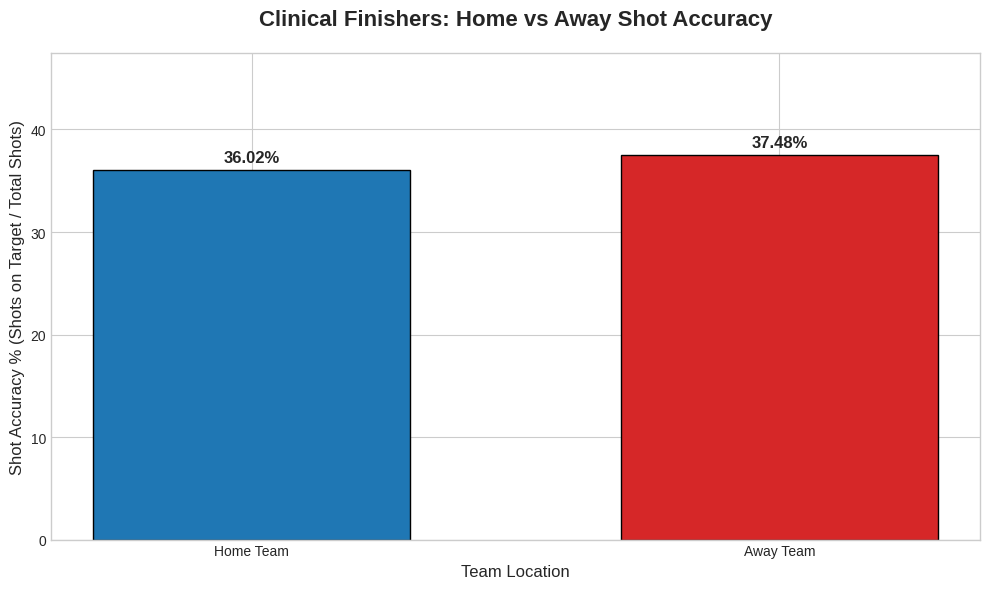

In [6]:

import matplotlib.pyplot as plt

print("RENDERING PREMIER LEAGUE GRAPHICS ENGINE...")

avg_home = master_df['Home_Accuracy'].mean() * 100
avg_away = master_df['Away_Accuracy'].mean() * 100

#Create the categories and values for the chart
categories = ['Home Team', 'Away Team']
values = [avg_home, avg_away]

#Set up the chart's "Canvas"
plt.figure(figsize=(10, 6)) # Image size (width, height)
plt.style.use('seaborn-v0_8-whitegrid') # A clean, modern visual style

#Create the bars with custom colors
# We use blue for Home and red for Away (classic rivalry colors)
bars = plt.bar(categories, values, color=['#1f77b4', '#d62728'], edgecolor='black', width=0.6)

#THE MAGIC: Putting the exact numbers on top of the bars ---
# This loop goes through each bar and "pastes" the formatted text (:.2f%) on it
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, # X coordinate (center of the bar)
             height + 0.5,                      # Y coordinate (slightly above the bar)
             f'{height:.2f}%',                  # The text to show (rounded to 2 decimals)
             ha='center',                       # Horizontal alignment (center)
             va='bottom',                       # Vertical alignment (bottom)
             fontweight='bold',                 # Bold text
             fontsize=12)                       # Font size

plt.title('Clinical Finishers: Home vs Away Shot Accuracy', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Shot Accuracy % (Shots on Target / Total Shots)', fontsize=12)
plt.xlabel('Team Location', fontsize=12)

#Adjust the Y-axis limits so the numbers don't get cut off at the top
plt.ylim(0, values[1] + 10)

plt.tight_layout() # Auto-adjust so nothing overlaps
plt.show()